In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/silver 100 years.csv


,Commodity,Minimum_Price,Maximum_Price,Mean_Price,Standard_Deviation,Price_Range,Range_Percent_of_Mean,Coefficient_of_Variation_%
1,Gold,19.25,5277.8900,397.551394,651.394525,5258.6400,1322.757277,163.851651
2,Silver,0.28,113.9528,6.421755,9.896696,113.6728,1770.120428,154.112017
0,Brent Oil,21.11,211.2100,62.709470,35.964228,190.1000,303.144005,57.350552


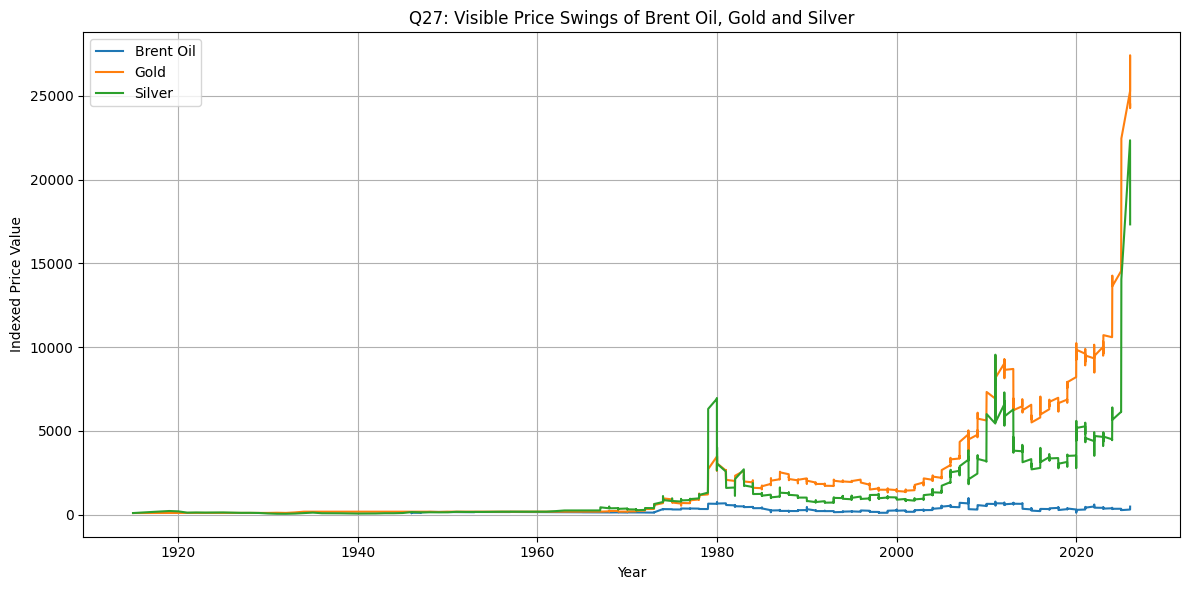

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

silver_df = pd.read_csv("/kaggle/input/datasets/ladkevinkumar/group9-dsb/silver 100 years.csv")
gold_df = pd.read_csv("/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv")
oil_df = pd.read_csv("/kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv")

silver_df["Commodity"] = "Silver"
gold_df["Commodity"] = "Gold"
oil_df["Commodity"] = "Brent Oil"

all_df = pd.concat([silver_df, gold_df, oil_df], ignore_index=True)

all_df["Date"] = pd.to_datetime(all_df["Date"], dayfirst=True, errors="coerce")
all_df["Value"] = pd.to_numeric(all_df["Value"], errors="coerce")

all_df = all_df.dropna(subset=["Date", "Value"])
all_df = all_df.sort_values(["Commodity", "Date"])

summary_table = all_df.groupby("Commodity")["Value"].agg(
    Minimum_Price="min",
    Maximum_Price="max",
    Mean_Price="mean",
    Standard_Deviation="std"
).reset_index()

summary_table["Price_Range"] = summary_table["Maximum_Price"] - summary_table["Minimum_Price"]
summary_table["Range_Percent_of_Mean"] = (summary_table["Price_Range"] / summary_table["Mean_Price"]) * 100
summary_table["Coefficient_of_Variation_%"] = (summary_table["Standard_Deviation"] / summary_table["Mean_Price"]) * 100

summary_table = summary_table.sort_values("Coefficient_of_Variation_%", ascending=False)

display(summary_table)

summary_table.to_csv("Q27_commodity_price_swing_summary.csv", index=False)

plt.figure(figsize=(12, 6))

for commodity in all_df["Commodity"].unique():
    temp_df = all_df[all_df["Commodity"] == commodity].copy()
    temp_df["Indexed_Value"] = (temp_df["Value"] / temp_df["Value"].iloc[0]) * 100
    plt.plot(temp_df["Date"], temp_df["Indexed_Value"], label=commodity)

plt.title("Q27: Visible Price Swings of Brent Oil, Gold and Silver")
plt.xlabel("Year")
plt.ylabel("Indexed Price Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Q27_commodity_price_swings_chart.pdf")
plt.show()